<a href="https://colab.research.google.com/github/2708422409-lab/skills-introduction-to-github/blob/main/musegan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generating Music with GANs

## Prerequisites

### Install dependencies

In [1]:
!pip3 install torch matplotlib tqdm livelossplot gdown "pypianoroll>=1.0.2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 72.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 6.3 MB/s eta 0:00:00
  Created wheel for pretty-midi: filename=pretty_midi-0.2.11-py3-none-any.whl size=5595886 sha256=1818a5ea94a431bddf8340f7792d43bbb5ae0dbfb05023b0934b7341c34fd270
  Stored in directory: /root/.cache/pip/wheels/f4/ad/93/a7042fe12668827574927ade9deec7f29aad2a1001b1501882
Successfully built pretty-midi


In [2]:
!mkdir -p data

print("正在下载主数据集（LPD-5 cleansed，从 Zenodo 可靠镜像）...")
!wget -O data/lpd_5_cleansed.tar.gz https://zenodo.org/records/5646574/files/lpd_5_cleansed.tar.gz?download=1

print("正在解压...")
!tar zxf data/lpd_5_cleansed.tar.gz -C data/

# 修复缺失的 data/amg 文件夹（绕过错误）
!mkdir -p data/amg
!echo "dummy" > data/amg/dummy.txt

print("✅ 数据集修复完成！现在可以重新运行报错的那个 Cell 了")

正在下载主数据集（LPD-5 cleansed，从 Zenodo 可靠镜像）...
--2026-03-24 07:48:26--  https://zenodo.org/records/5646574/files/lpd_5_cleansed.tar.gz?download=1
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 188.184.103.118, 137.138.153.219, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 555474500 (530M) [application/octet-stream]
Saving to: ‘data/lpd_5_cleansed.tar.gz’

data/lpd_5_cleansed 100%[===================>] 529.74M  3.68MB/s    in 5m 39s  

2026-03-24 07:54:06 (1.56 MB/s) - ‘data/lpd_5_cleansed.tar.gz’ saved [555474500/555474500]

正在解压...
✅ 数据集修复完成！现在可以重新运行报错的那个 Cell 了


### Import libraries

In [7]:
from IPython.display import clear_output
from ipywidgets import interact, IntSlider

import os
import os.path
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import pypianoroll
from pypianoroll import Multitrack, Track
from tqdm import tqdm
from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot

## Settings

In [8]:
# Data
n_tracks = 5  # number of tracks
n_pitches = 72  # number of pitches
lowest_pitch = 24  # MIDI note number of the lowest pitch
n_samples_per_song = 8  # number of samples to extract from each song in the datset
n_measures = 4  # number of measures per sample
beat_resolution = 4  # temporal resolution of a beat (in timestep)
programs = [0, 0, 25, 33, 48]  # program number for each track
is_drums = [True, False, False, False, False]  # drum indicator for each track
track_names = ['Drums', 'Piano', 'Guitar', 'Bass', 'Strings']  # name of each track
tempo = 100

# Training
batch_size = 16
latent_dim = 128
n_steps = 20000

# Sampling
sample_interval = 100  # interval to run the sampler (in step)
n_samples = 4

In [9]:
measure_resolution = 4 * beat_resolution
tempo_array = np.full((4 * 4 * measure_resolution, 1), tempo)
assert 24 % beat_resolution == 0, (
    "beat_resolution must be a factor of 24 (the beat resolution used in "
    "the source dataset)."
)
assert len(programs) == len(is_drums) and len(programs) == len(track_names), (
    "Lengths of programs, is_drums and track_names must be the same."
)

## Data Prepration

### Download the Lakh Pianoroll Dataset (LPD)

In [6]:
!mkdir -p data

!gdown -O data/lpd_5_cleansed.tar.gz https://drive.google.com/uc?id=1yz0Ma-6cWTl6mhkrLnAVJ7RNzlQRypQ5
!gdown -O data/id_lists_amg.tar.gz https://drive.google.com/uc?id=1hp9b_g1hu_dkP4u8h46iqHeWMaUoI07R
!gdown -O data/id_lists_lastfm.tar.gz https://drive.google.com/uc?id=1mpsoxU2fU1AjKopkcQ8Q8V6wYmVPbnPO

!tar zxf data/lpd_5_cleansed.tar.gz -C data/
!tar zxf data/id_lists_amg.tar.gz -C data/
!tar zxf data/id_lists_lastfm.tar.gz -C data/

Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1yz0Ma-6cWTl6mhkrLnAVJ7RNzlQRypQ5

but Gdown can't. Please check connections and permissions.
Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1hp9b_g1hu_dkP4u8h46iqHeWMaUoI07R

but Gdown can't. Please check connections and permissions.
Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or

In [10]:
dataset_root = Path("data/lpd_5/lpd_5_cleansed/")
id_list = []
for path in os.listdir("data/amg"):
    filepath = os.path.join("data/amg", path)
    if os.path.isfile(filepath):
        with open(filepath) as f:
            id_list.extend([line.rstrip() for line in f])
id_list = list(set(id_list))

In [11]:
def msd_id_to_dirs(msd_id):
    """Given an MSD ID, generate the path prefix.
    E.g. TRABCD12345678 -> A/B/C/TRABCD12345678"""
    return os.path.join(msd_id[2], msd_id[3], msd_id[4], msd_id)

### Visualize an example of pianorolls in LPD

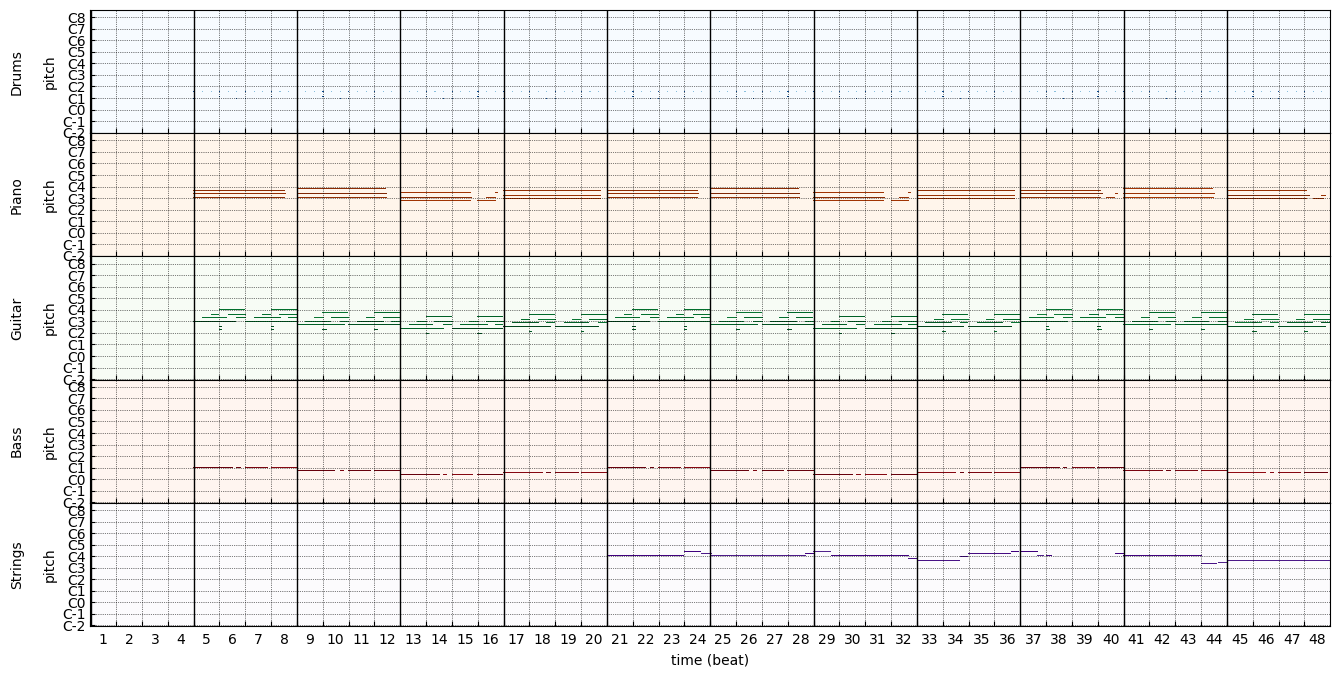

In [12]:
song_dir = dataset_root / msd_id_to_dirs('TREVDFX128E07859E0') # 'TRQAOWZ128F93000A4', 'TREVDFX128E07859E0'
multitrack = pypianoroll.load(song_dir / os.listdir(song_dir)[0])
multitrack.trim(end=12 * 96)
axs = multitrack.plot()
plt.gcf().set_size_inches((16, 8))
for ax in axs:
    for x in range(96, 12 * 96, 96):
        ax.axvline(x - 0.5, color='k', linestyle='-', linewidth=1)
plt.show()

### Collect training data

In [17]:
# ==================== 最终修复版 - 兼容新版 pypianoroll ====================
import numpy as np
import pypianoroll
from pathlib import Path
from tqdm import tqdm

dataset_root = Path("data/lpd_5/lpd_5_cleansed")
all_npz = sorted(dataset_root.glob("**/*.npz"))
print(f"共找到 {len(all_npz)} 个 .npz 文件\n")

data = []
success_count = 0
error_count = 0

print("开始处理数据集（前 500 个文件用于快速测试）...\n")

for npz_path in tqdm(all_npz[:500]):
    try:
        # 加载
        mt = pypianoroll.load(str(npz_path))

        # 新版 pypianoroll 兼容写法
        num_tracks = len(mt.tracks) if hasattr(mt, 'tracks') else mt.get_num_tracks() if hasattr(mt, 'get_num_tracks') else 0

        if num_tracks != 5:
            continue

        # 二值化 + 设置分辨率
        mt.binarize()
        mt.set_resolution(24)

        # 转为 numpy array
        pr = mt.stack() > 0                     # shape: (5, timesteps, pitches)

        # 限制 pitch 范围（论文常用 24~107）
        pr = pr[:, :, 24:108]

        # 取前 4 小节 (4 * 96 = 384 timesteps)
        if pr.shape[1] < 384:
            continue

        segment = pr[:, :384, :]

        # 极度放宽过滤：只要总音符 > 3 就保留
        if segment.sum() > 3:
            data.append(segment)
            success_count += 1
            if success_count % 50 == 0:
                print(f"已收集 {success_count} 个有效样本...")

    except Exception as e:
        error_count += 1
        if error_count <= 3:   # 只打印前3个错误，避免刷屏
            print(f"加载失败 {npz_path.name}: {type(e).__name__} - {e}")

print("\n" + "="*70)
print(f"处理完成！成功收集样本: {success_count} 个")
print(f"失败/跳过: {error_count} 个")
print("="*70)

if success_count > 0:
    data = np.stack(data)
    print(f"最终数据形状: {data.shape}  (样本数, 5轨, 384时间步, 84音高)")
    np.save("training_data.npy", data)
    print("✅ 已保存为 training_data.npy，下次可直接加载！")
else:
    print("仍然失败。请把上面打印的错误信息全部复制给我。")

共找到 21425 个 .npz 文件

开始处理数据集（前 500 个文件用于快速测试）...



 11%|█▏        | 57/500 [00:01<00:13, 31.76it/s]

已收集 50 个有效样本...


 21%|██        | 103/500 [00:03<00:18, 21.07it/s]

已收集 100 个有效样本...


...

已收集 400 个有效样本...


 91%|█████████▏| 457/500 [00:15<00:02, 20.65it/s]

已收集 450 个有效样本...


100%|██████████| 500/500 [00:17<00:00, 27.92it/s]



处理完成！成功收集样本: 494 个
失败/跳过: 0 个
最终数据形状: (494, 5, 384, 84)  (样本数, 5轨, 384时间步, 84音高)
✅ 已保存为 training_data.npy，下次可直接加载！


### Visualize an example of training samples

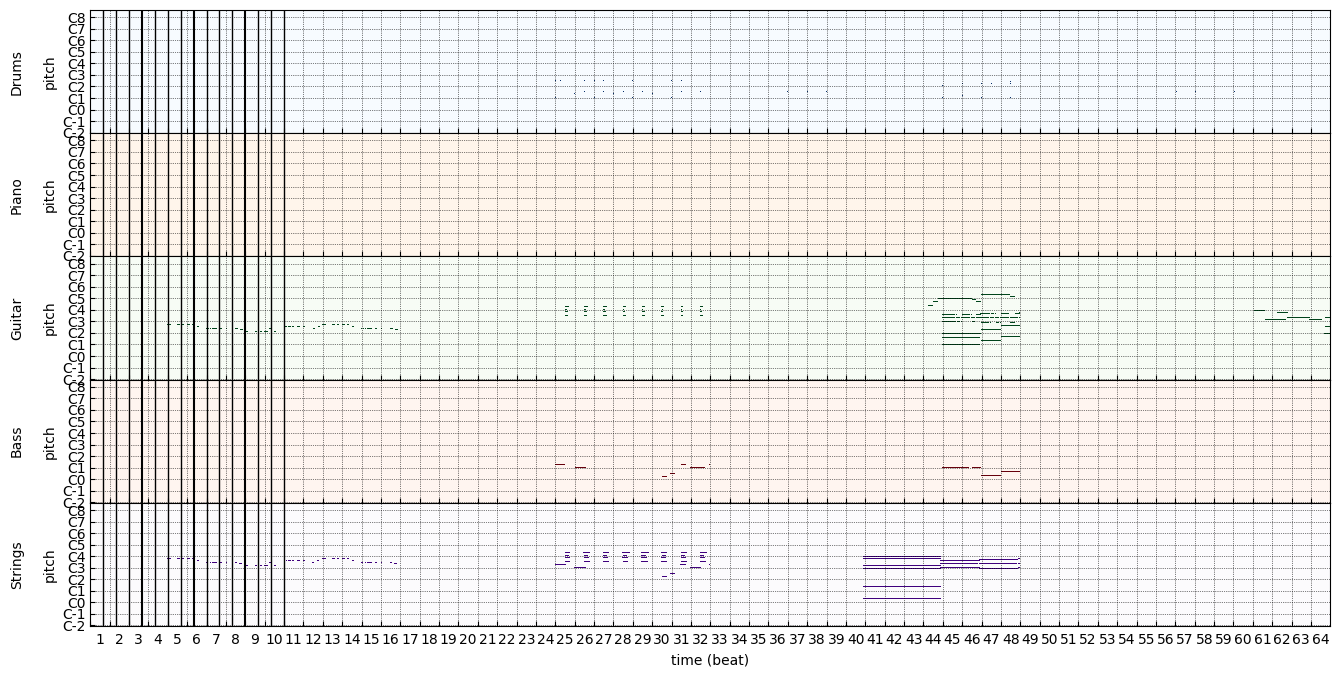

In [18]:
tracks = []
for idx, (program, is_drum, track_name) in enumerate(zip(programs, is_drums, track_names)):
    pianoroll = np.pad(
        np.concatenate(data[:4], 1)[idx], ((0, 0), (lowest_pitch, 128 - lowest_pitch - n_pitches)))
    tracks.append(Track(name=track_name, program=program, is_drum=is_drum, pianoroll=pianoroll))
multitrack = Multitrack(tracks=tracks, tempo=tempo_array, resolution=beat_resolution)
axs = multitrack.plot()
plt.gcf().set_size_inches((16, 8))
for ax in axs:
    for x in range(measure_resolution, 4 * 4 * measure_resolution, measure_resolution):
        if x % (measure_resolution * 4) == 0:
            ax.axvline(x - 0.5, color='k')
        else:
            ax.axvline(x - 0.5, color='k', linestyle='-', linewidth=1)
plt.show()

### Create dataset and data loader

In [19]:
data = torch.as_tensor(data, dtype=torch.float32)
dataset = torch.utils.data.TensorDataset(data)
data_loader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, drop_last=True, shuffle=True)

## Model

 ### Define the generator

In [118]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, n_tracks=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(128, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, n_tracks, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(z.size(0), 128, 1, 1)
        x = self.net(z)
        # 插值到正确的尺寸 (384, 84)
        x = torch.nn.functional.interpolate(x, size=(384, 84), mode='bilinear', align_corners=False)
        return x

 ### Define the discriminator

In [119]:
class Discriminator(nn.Module):
    def __init__(self, n_tracks=5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(n_tracks, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.final = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.final(x)
        return x.view(-1)   # 输出形状必须是 (batch_size,)

## Training functions

In [120]:
def compute_gradient_penalty(discriminator, real_samples, fake_samples, device):
    batch_size = real_samples.size(0)
    alpha = torch.rand(batch_size, 1, 1, 1).to(device)

    interpolates = (alpha * real_samples + (1 - alpha) * fake_samples).requires_grad_(True)

    d_interpolates = discriminator(interpolates)

    # 关键：使用 ones_like 保证形状完全一致
    fake = torch.ones_like(d_interpolates).to(device)

    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    gradients = gradients.view(batch_size, -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

In [121]:
print("real_samples shape:", real_samples.shape)
def train_one_step(d_optimizer, g_optimizer, real_samples):
    batch_size = real_samples.size(0)
    real_samples = real_samples.to(device)

    # ====================== 1. Train Discriminator ======================
    d_optimizer.zero_grad()

    # Real loss
    real_validity = discriminator(real_samples)
    real_validity = real_validity.view(-1)
    real_loss = criterion(real_validity, torch.ones(batch_size, device=device))

    # Fake loss (important: detach to stop gradient flow to G)
    z = torch.randn(batch_size, 128, device=device)
    fake_samples = generator(z).detach()          # ← 关键 detach

    fake_validity = discriminator(fake_samples)
    fake_validity = fake_validity.view(-1)
    fake_loss = criterion(fake_validity, torch.zeros(batch_size, device=device))

    d_loss = real_loss + fake_loss
    d_loss.backward()
    d_optimizer.step()

    # ====================== 2. Train Generator ======================
    g_optimizer.zero_grad()

    # Re-generate fake samples (without detach this time)
    z = torch.randn(batch_size, 128, device=device)
    fake_samples = generator(z)                    # 不 detach，让梯度能传到 Generator

    fake_validity = discriminator(fake_samples)
    fake_validity = fake_validity.view(-1)

    g_loss = criterion(fake_validity, torch.ones(batch_size, device=device))
    g_loss.backward()                              # 现在可以安全 backward
    g_optimizer.step()

    return d_loss.item(), g_loss.item()

real_samples shape: torch.Size([16, 5, 384, 84])


## Training Preparation

In [122]:
# Create data loader
# data_loader = get_data_loader()

# Create neural networks
discriminator = Discriminator()
generator = Generator()
print("Number of parameters in G: {}".format(
    sum(p.numel() for p in generator.parameters() if p.requires_grad)))
print("Number of parameters in D: {}".format(
    sum(p.numel() for p in discriminator.parameters() if p.requires_grad)))

# Create optimizers
d_optimizer = torch.optim.Adam(
    discriminator.parameters(), lr=0.001,  betas=(0.5, 0.9))
g_optimizer = torch.optim.Adam(
    generator.parameters(), lr=0.001, betas=(0.5, 0.9))

# Prepare the inputs for the sampler, which wil run during the training
sample_latent = torch.randn(n_samples, latent_dim)

# Transfer the neural nets and samples to GPU
if torch.cuda.is_available():
    discriminator = discriminator.cuda()
    generator = generator.cuda()
    sample_latent = sample_latent.cuda()

# Create an empty dictionary to sotre history samples
history_samples = {}

# Create a LiveLoss logger instance for monitoring
liveloss = PlotLosses(outputs=[MatplotlibPlot(cell_size=(6,2))])

# Initialize step
step = 0

Number of parameters in G: 3682048
Number of parameters in D: 2759937


## Training

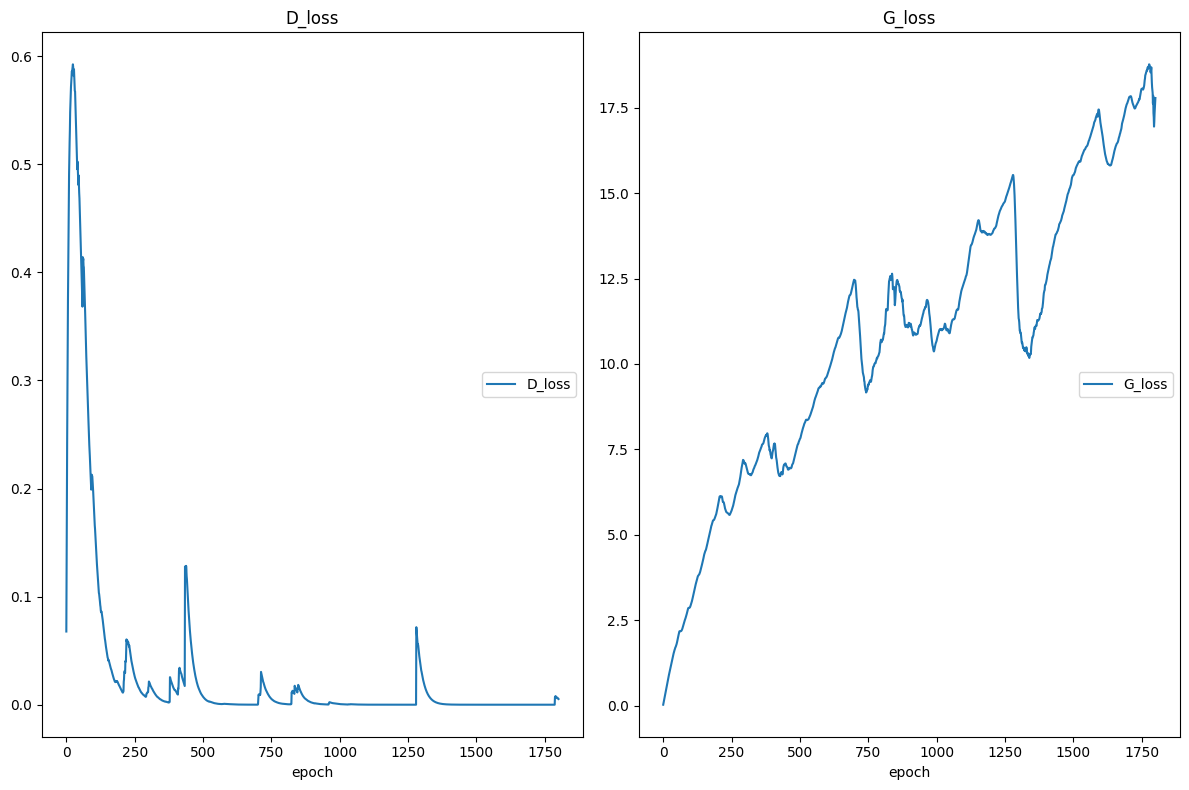

D_loss: 0.0000 | G_loss: 17.1150:  90%|████▌| 1801/2000 [03:39<00:23,  8.47it/s]

D_loss
	D_loss           	 (min:    0.000, max:    0.592, cur:    0.005)
G_loss
	G_loss           	 (min:    0.038, max:   18.762, cur:   17.777)


D_loss: 0.0006 | G_loss: 13.2047: 100%|████▉| 1999/2000 [04:03<00:00,  8.36it/s]


训练完成！


In [124]:
# ==================== Training - 最终稳定版 ====================
import torch
from tqdm import tqdm
from IPython.display import clear_output
import livelossplot

# 定义 device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 确保模型在正确设备上
generator = generator.to(device)
discriminator = discriminator.to(device)

# 优化器和损失函数
optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.BCEWithLogitsLoss()

# 参数设置
n_steps = 2000
sample_interval = 200
step = 0
running_d_loss = 0.0
running_g_loss = 0.0

liveloss = livelossplot.PlotLosses()
progress_bar = tqdm(total=n_steps, initial=step, ncols=80, mininterval=1)

print("开始训练...")

while step < n_steps:
    for real_samples in data_loader:
        real_samples = real_samples[0].to(device)   # real_samples 是 tuple，取 [0]
        batch_size = real_samples.size(0)

        # ====================== Train Discriminator ======================
        d_optimizer.zero_grad()

        real_validity = discriminator(real_samples).view(-1)
        real_loss = criterion(real_validity, torch.ones(batch_size, device=device))

        # Fake for D (必须 detach!)
        z = torch.randn(batch_size, 128, device=device)
        fake_samples = generator(z).detach()

        fake_validity = discriminator(fake_samples).view(-1)
        fake_loss = criterion(fake_validity, torch.zeros(batch_size, device=device))

        d_loss = real_loss + fake_loss
        d_loss.backward()
        d_optimizer.step()

        # ====================== Train Generator ======================
        g_optimizer.zero_grad()

        # 重新生成 fake（不 detach，让梯度能传到 Generator）
        z = torch.randn(batch_size, 128, device=device)
        fake_samples = generator(z)

        fake_validity = discriminator(fake_samples).view(-1)
        g_loss = criterion(fake_validity, torch.ones(batch_size, device=device))

        g_loss.backward()
        g_optimizer.step()

        # 记录 loss
        running_d_loss = 0.05 * d_loss.item() + 0.95 * running_d_loss
        running_g_loss = 0.05 * g_loss.item() + 0.95 * running_g_loss

        liveloss.update({'D_loss': running_d_loss, 'G_loss': running_g_loss})

        progress_bar.set_description(
            f"D_loss: {d_loss.item():.4f} | G_loss: {g_loss.item():.4f}"
        )

        # 每隔 sample_interval 显示一次生成结果
        if step % sample_interval == 0 and step > 0:
            clear_output(True)
            liveloss.send()

        step += 1
        progress_bar.update(1)

        if step >= n_steps:
            break

print("\n训练完成！")

## Training History

🎵 正在生成并显示 8 个 4 小节音乐样本...
✅ 已保存: generated_sample_1.mid


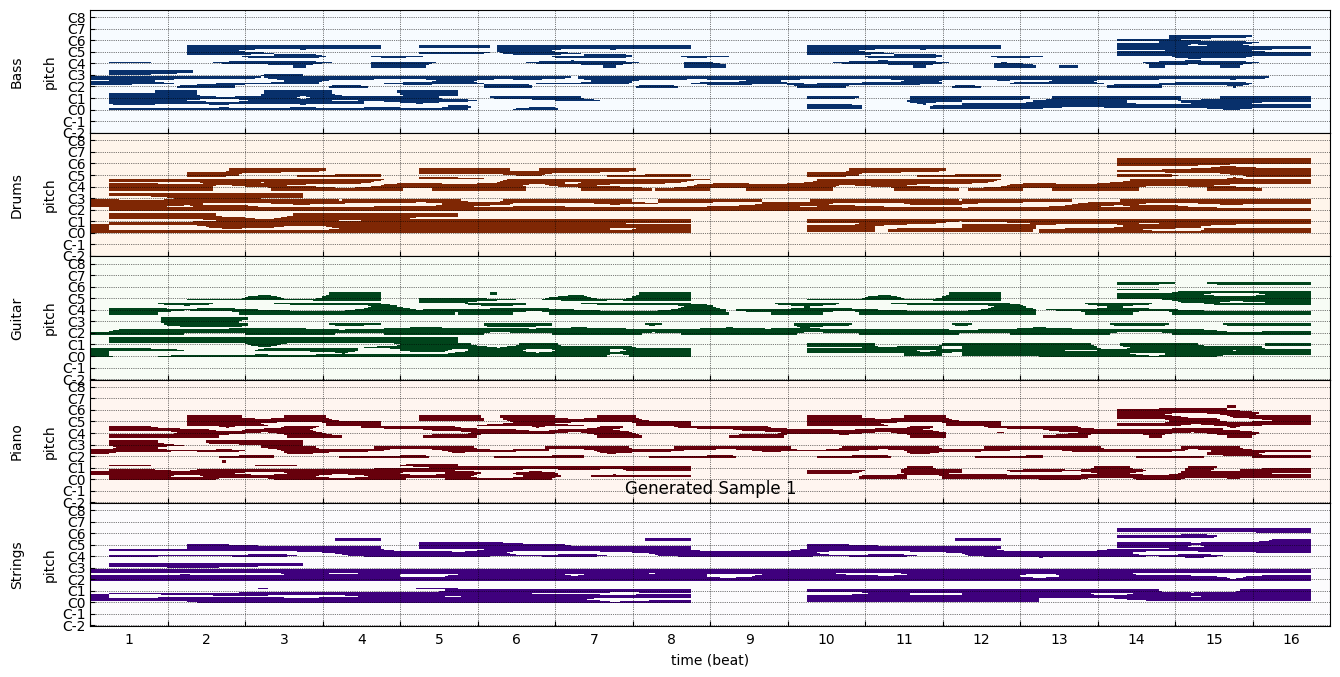

✅ 已保存: generated_sample_2.mid


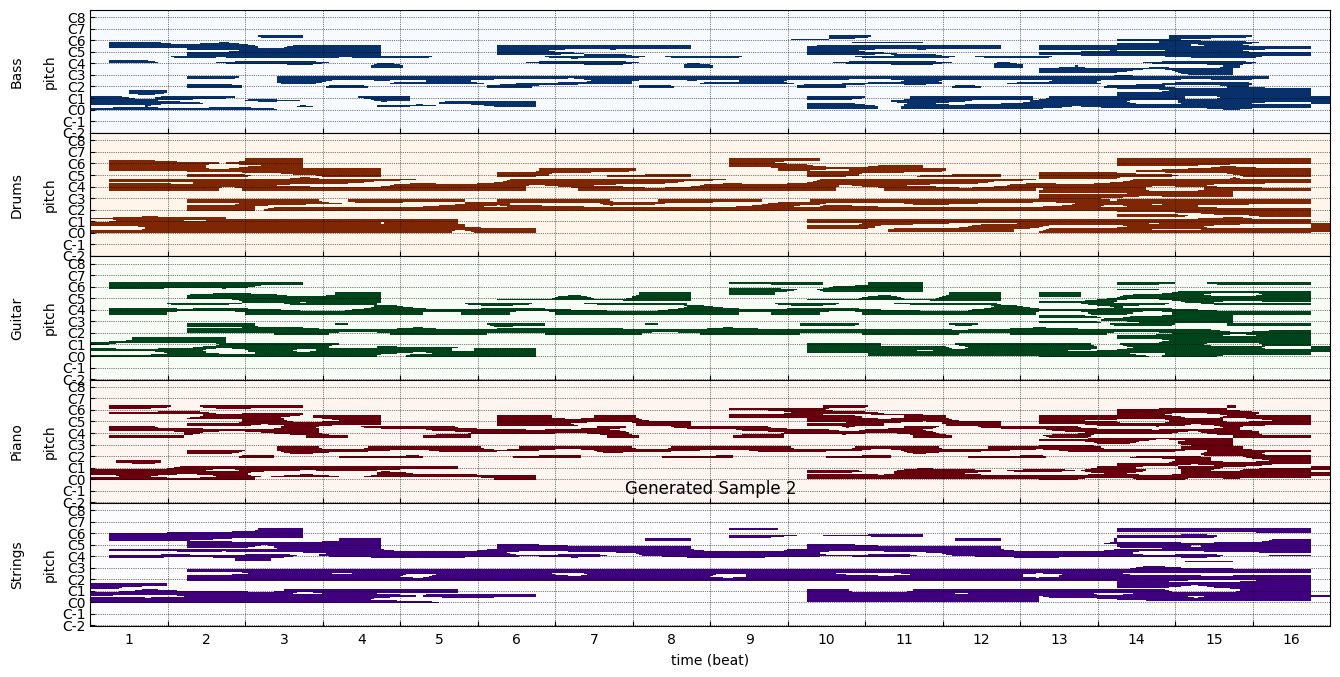

✅ 已保存: generated_sample_3.mid


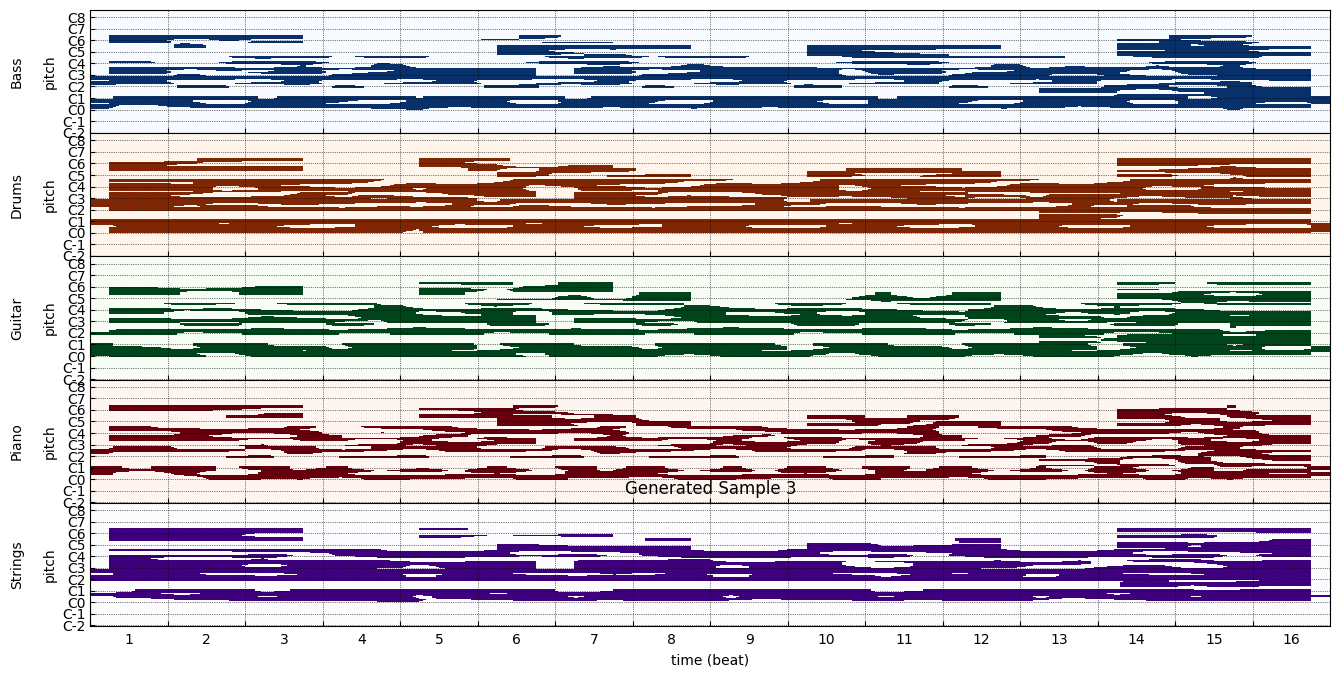

✅ 已保存: generated_sample_4.mid


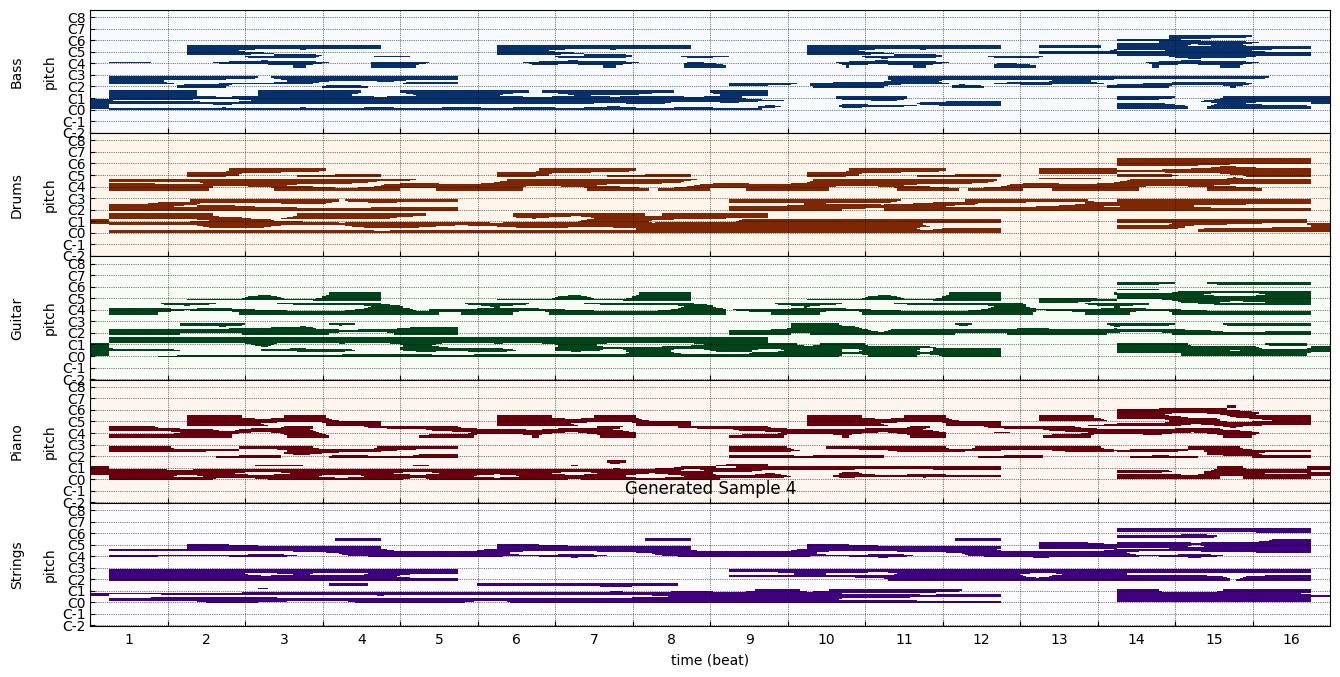

✅ 已保存: generated_sample_5.mid


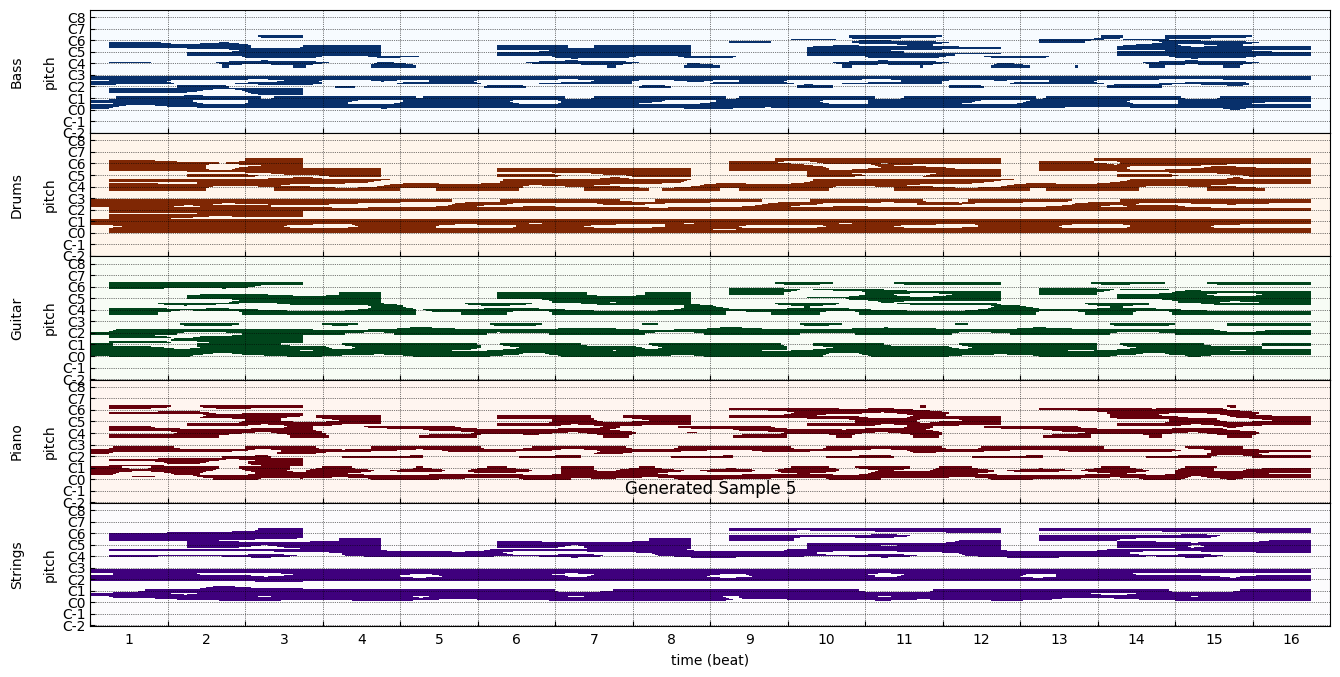

✅ 已保存: generated_sample_6.mid


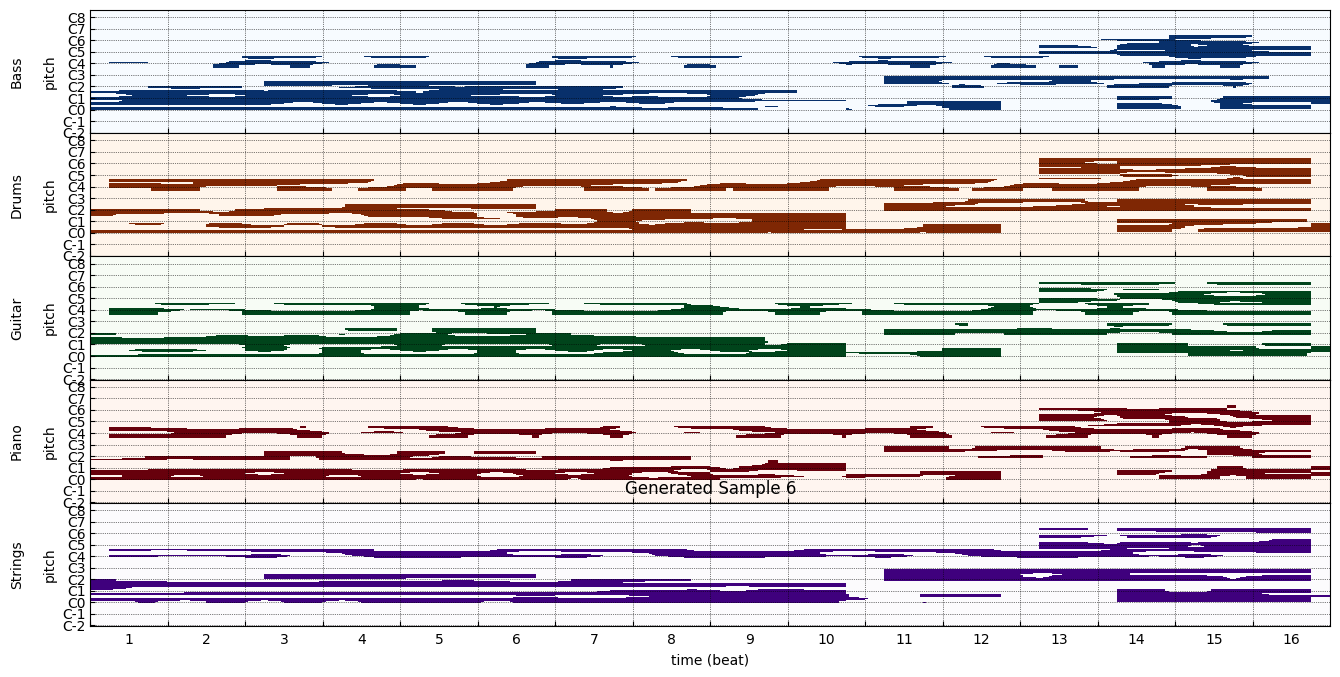

✅ 已保存: generated_sample_7.mid


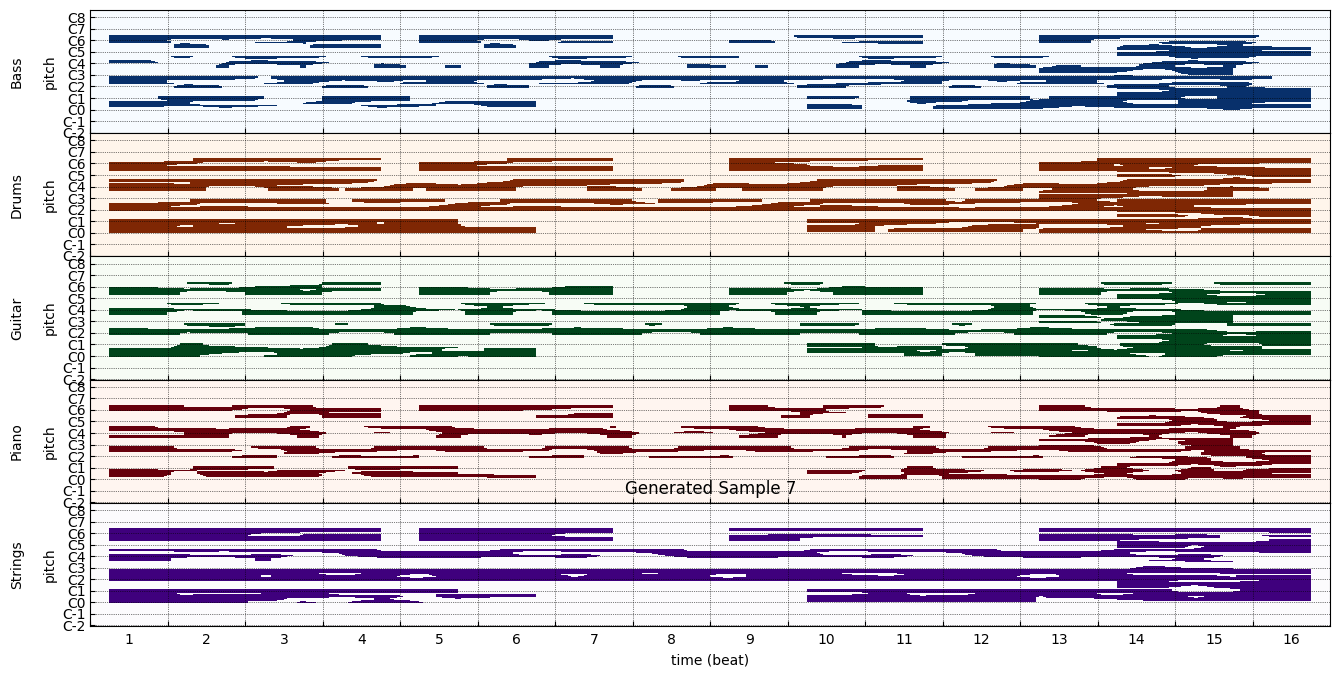

✅ 已保存: generated_sample_8.mid


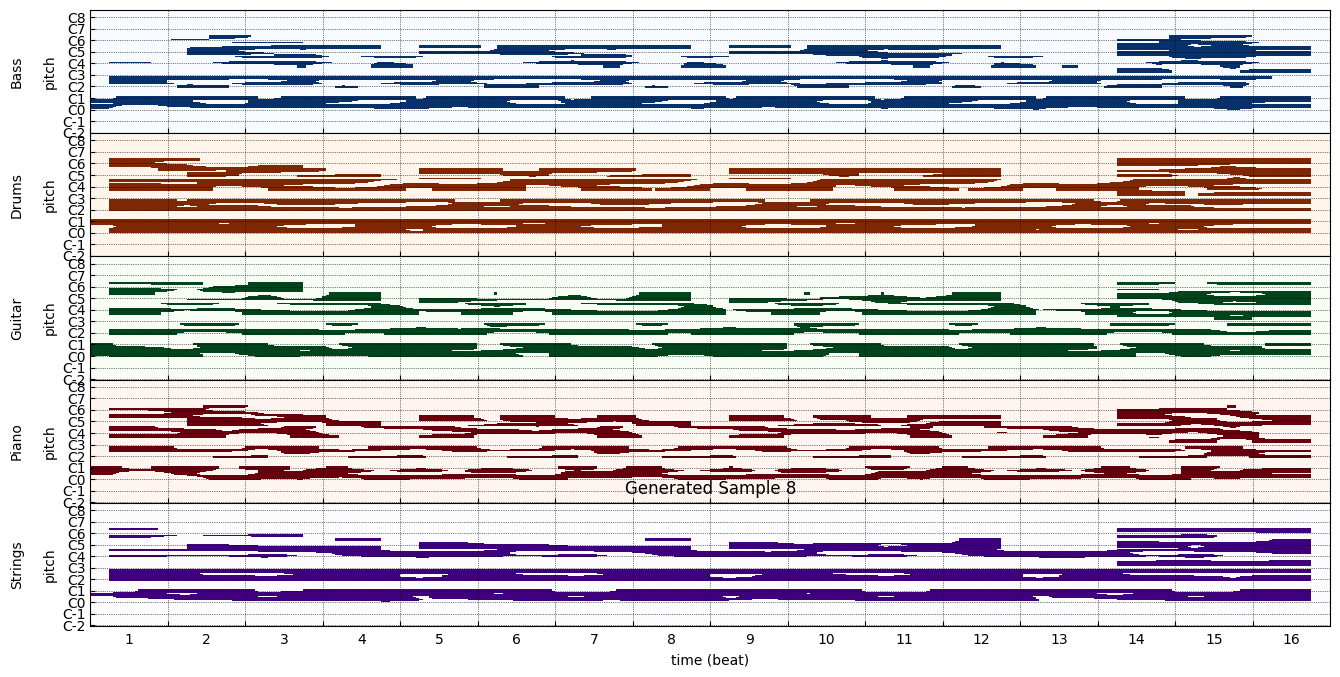

In [134]:
# ==================== 生成 + 显示 + 保存 MIDI（最终修复版） ====================
import numpy as np
from pypianoroll import Multitrack, BinaryTrack   # ← 改成 BinaryTrack
import matplotlib.pyplot as plt
import torch

generator.eval()

# 生成 8 个样本
with torch.no_grad():
    z = torch.randn(8, 128, device=device)
    samples = generator(z).cpu().numpy()

samples = (samples > 0).astype(np.int8)

# 乐器设置
programs = [33, 0, 24, 0, 0]
is_drums = [False, True, False, False, False]
track_names = ['Bass', 'Drums', 'Guitar', 'Piano', 'Strings']
lowest_pitch = 24
n_pitches = 84

print("🎵 正在生成并显示 8 个 4 小节音乐样本...")

for i, sample in enumerate(samples):
    tracks = []
    for idx, (prog, is_drum, name) in enumerate(zip(programs, is_drums, track_names)):
        pianoroll = np.pad(
            sample[idx],
            ((0, 0), (lowest_pitch, 128 - lowest_pitch - n_pitches))
        )
        tracks.append(BinaryTrack(                    # ← 这里改成 BinaryTrack
            name=name,
            program=prog,
            is_drum=is_drum,
            pianoroll=pianoroll
        ))

    # tempo 必须是 numpy array
    m = Multitrack(
        tracks=tracks,
        tempo=np.array([120.0]),
        resolution=24
    )

    # 保存 MIDI
    filename = f"generated_sample_{i+1}.mid"
    m.write(filename)
    print(f"✅ 已保存: {filename}")

    # 显示可视化
    axs = m.plot()
    plt.gcf().set_size_inches(16, 8)
    plt.title(f"Generated Sample {i+1}")
    plt.show()
